In [ ]:
# Bloque 1: NumPy y Pandas — Fundamentos y Limpieza

In [2]:
# Ejercicio 1 · Filtrado Condicional y Reemplazo

import numpy as np
import pandas as pd

np.random.seed(42)

arr = np.random.randint(1, 1001, size=100)
df1 = pd.DataFrame(arr.astype(float), columns=["Valores"])

mascara_mult = (df1["Valores"] % 3 == 0) | (df1["Valores"] % 5 == 0)
media_no_mult = df1.loc[~mascara_mult, "Valores"].mean()

df1.loc[mascara_mult, "Valores"] = media_no_mult

print(f"Media usada para reemplazo: {media_no_mult:.2f}")
print(df1.describe())

Media usada para reemplazo: 480.56
          Valores
count  100.000000
mean   480.562500
std    240.780208
min      2.000000
25%    345.500000
50%    480.562500
75%    563.750000
max    976.000000


In [3]:
# ejercicio 2: Manejo de Outliers con IQR
salarios = np.concatenate([
    np.random.normal(50000, 10000, 95),
    [5000, 3000, 150000, 200000, 180000]   # outliers artificiales
])
df2 = pd.DataFrame({"Salario": salarios})

Q1  = df2["Salario"].quantile(0.25)
Q3  = df2["Salario"].quantile(0.75)
IQR = Q3 - Q1

p5  = df2["Salario"].quantile(0.05)
p95 = df2["Salario"].quantile(0.95)

df2["Salario"] = df2["Salario"].clip(lower=p5, upper=p95)

print(f"Q1={Q1:.0f} | Q3={Q3:.0f} | IQR={IQR:.0f}")
print(f"Límite inferior IQR: {Q1 - 1.5*IQR:.0f}  → reemplazado por P5={p5:.0f}")
print(f"Límite superior IQR: {Q3 + 1.5*IQR:.0f} → reemplazado por P95={p95:.0f}")
print(df2["Salario"].describe())

Q1=41556 | Q3=57653 | IQR=16098
Límite inferior IQR: 17409  → reemplazado por P5=31615
Límite superior IQR: 81800 → reemplazado por P95=73554
count      100.000000
mean     50408.701670
std      11319.769665
min      31614.620840
25%      41555.734756
50%      49367.391953
75%      57653.279256
max      73553.854284
Name: Salario, dtype: float64


In [4]:
# Ejercicio 3 · Reestructuración con Melt
df3_wide = pd.DataFrame({
    "Producto": ["Producto_A", "Producto_B", "Producto_C"],
    "Enero":    [1200, 980, 1500],
    "Febrero":  [1350, 1100, 1420],
    "Marzo":    [1280, 1050, 1600],
})

df3_long = df3_wide.melt(
    id_vars="Producto",
    value_vars=["Enero", "Febrero", "Marzo"],
    var_name="Mes",
    value_name="Ventas"
)

print(df3_long)

     Producto      Mes  Ventas
0  Producto_A    Enero    1200
1  Producto_B    Enero     980
2  Producto_C    Enero    1500
3  Producto_A  Febrero    1350
4  Producto_B  Febrero    1100
5  Producto_C  Febrero    1420
6  Producto_A    Marzo    1280
7  Producto_B    Marzo    1050
8  Producto_C    Marzo    1600


In [5]:
# Ejercicio 4 · Porcentaje de Horas por Departamento
df4 = pd.DataFrame({
    "Departamento": ["Ventas","Ventas","Ventas","IT","IT","RRHH","RRHH","RRHH"],
    "Proyecto":     ["P1","P2","P3","P4","P5","P6","P7","P8"],
    "Horas":        [40, 60, 50, 80, 70, 30, 45, 25],
})

df4["Porcentaje_Depto"] = df4.groupby("Departamento")["Horas"].transform(
    lambda x: (x / x.sum()) * 100
)

print(df4.to_string(index=False))

Departamento Proyecto  Horas  Porcentaje_Depto
      Ventas       P1     40         26.666667
      Ventas       P2     60         40.000000
      Ventas       P3     50         33.333333
          IT       P4     80         53.333333
          IT       P5     70         46.666667
        RRHH       P6     30         30.000000
        RRHH       P7     45         45.000000
        RRHH       P8     25         25.000000


In [6]:
# Ejercicio 5 · Serie de Tiempo con Interpolación Lineal
rango_completo = pd.date_range("2026-01-01", "2026-01-15", freq="D")
fechas_muestra = pd.to_datetime(
    np.sort(np.random.choice(rango_completo, size=9, replace=False))
)
valores = np.random.randint(100, 500, size=9).astype(float)

serie = pd.Series(valores, index=fechas_muestra)
serie = serie.reindex(rango_completo)          # introduce NaN en fechas faltantes
serie_interpolada = serie.interpolate(method="linear")

print(pd.DataFrame({"Original": serie, "Interpolada": serie_interpolada}).to_string())

            Original  Interpolada
2026-01-01       NaN          NaN
2026-01-02     246.0   246.000000
2026-01-03     247.0   247.000000
2026-01-04     451.0   451.000000
2026-01-05     298.0   298.000000
2026-01-06       NaN   352.500000
2026-01-07     407.0   407.000000
2026-01-08     227.0   227.000000
2026-01-09       NaN   182.500000
2026-01-10     138.0   138.000000
2026-01-11       NaN   237.666667
2026-01-12       NaN   337.333333
2026-01-13     437.0   437.000000
2026-01-14     459.0   459.000000
2026-01-15       NaN   459.000000


In [ ]:
# Bloque 2: Manipulación Avanzada de Datos


In [7]:
# Ejercicio 6 · Tabla Cruzada de Satisfacción
n = 300
df6 = pd.DataFrame({
    "Categoria_Producto": np.random.choice(["Electrónica", "Ropa", "Hogar"], n),
    "Metodo_Pago":        np.random.choice(["Efectivo", "Tarjeta", "Transferencia"], n),
    "Satisfecho":         np.random.choice(["Si", "No"], n, p=[0.65, 0.35]),
})

ct = pd.crosstab(
    index=[df6["Categoria_Producto"], df6["Metodo_Pago"]],
    columns=df6["Satisfecho"],
    normalize="index"
) * 100

print(ct.round(1).to_string())

Satisfecho                          No    Si
Categoria_Producto Metodo_Pago              
Electrónica        Efectivo       29.5  70.5
                   Tarjeta        35.7  64.3
                   Transferencia  22.2  77.8
Hogar              Efectivo       23.3  76.7
                   Tarjeta        19.4  80.6
                   Transferencia  24.0  76.0
Ropa               Efectivo       36.4  63.6
                   Tarjeta        30.3  69.7
                   Transferencia  31.0  69.0


In [8]:
# Ejercicio 7 · Merge Complejo
df_usuarios = pd.DataFrame({
    "ID":     range(1, 11),
    "Nombre": [f"Usuario_{i}" for i in range(1, 11)],
    "Pais":   ["Colombia","México","Argentina","Colombia","Chile",
               "México","Perú","Colombia","México","Brasil"],
})

df_transacciones = pd.DataFrame({
    "ID_Transaccion": range(101, 121),
    "ID_Usuario":     np.random.choice(range(1, 11), 20),
    "Monto":          np.random.uniform(10, 5000, 20).round(2),
    "Fecha":          pd.date_range("2026-01-01", periods=20, freq="3D"),
})

promedio_global = df_transacciones["Monto"].mean()
txn_sobre_prom  = df_transacciones[df_transacciones["Monto"] > promedio_global]

df7 = df_usuarios[df_usuarios["Pais"].isin(["Colombia", "México"])].merge(
    txn_sobre_prom, left_on="ID", right_on="ID_Usuario"
)

print(f"Promedio global: ${promedio_global:.2f}")
print(df7[["ID", "Nombre", "Pais", "Monto", "Fecha"]].to_string(index=False))

Promedio global: $3010.13
 ID    Nombre     Pais   Monto      Fecha
  1 Usuario_1 Colombia 3522.69 2026-01-19
  2 Usuario_2   México 3127.56 2026-01-25
  4 Usuario_4 Colombia 4154.97 2026-02-09
  6 Usuario_6   México 3682.16 2026-01-04
  6 Usuario_6   México 3871.43 2026-02-15
  8 Usuario_8 Colombia 3169.87 2026-01-01
  8 Usuario_8 Colombia 4554.01 2026-01-22
  8 Usuario_8 Colombia 4127.29 2026-01-31
  9 Usuario_9   México 4242.16 2026-01-07


In [9]:
# Ejercicio 8 · Binning de Edades
df8 = pd.DataFrame({
    "Edad":     np.random.randint(5, 85, 200),
    "Ingresos": np.random.normal(45000, 15000, 200).clip(5000),
})

bins   = [0, 18, 35, 60, 120]
labels = ["Junior", "Young Adult", "Adult", "Senior"]
df8["Grupo_Edad"] = pd.cut(df8["Edad"], bins=bins, labels=labels, right=True)

resumen = df8.groupby("Grupo_Edad", observed=True).agg(
    Conteo         = ("Edad",     "count"),
    Media_Ingresos = ("Ingresos", "mean")
).round(2)

print(resumen)

             Conteo  Media_Ingresos
Grupo_Edad                         
Junior           32        51399.53
Young Adult      50        45805.98
Adult            64        45963.63
Senior           54        48834.13


In [10]:
# Ejercicio 9 · Ventana Móvil (Rolling)
fechas_acc = pd.date_range("2026-01-01", periods=60, freq="B")
precios    = 100 + np.cumsum(np.random.normal(0, 1.5, 60))

df9 = pd.DataFrame({"Precio": precios}, index=fechas_acc)
df9["Media_Movil_5d"] = df9["Precio"].rolling(window=5).mean()
df9["Desv_Movil_5d"]  = df9["Precio"].rolling(window=5).std()

print(df9.tail(10).round(4))

             Precio  Media_Movil_5d  Desv_Movil_5d
2026-03-12  93.7517         93.0850         1.1099
2026-03-13  96.7092         93.6858         1.9920
2026-03-16  96.3895         94.1655         2.3420
2026-03-17  96.4911         94.9338         2.3504
2026-03-18  97.0913         96.0865         1.3327
2026-03-19  97.3133         96.7989         0.3939
2026-03-20  94.8019         96.4174         0.9840
2026-03-23  95.4437         96.2283         1.0772
2026-03-24  92.3119         95.3924         2.0259
2026-03-25  91.2128         94.2167         2.4540


In [11]:
# Ejercicio 10 · Parseo de Fechas y Extracciones
df10 = pd.DataFrame({
    "Fecha_Raw": [
        "2026-04-15 14:30:00", "15/04/2026",
        "2026-01-20 09:00:00", "22/03/2026",
        "2026-07-04 18:45:00",
    ]
})

# Parseo en dos pasadas para cubrir ambos formatos
df10["Fecha"] = pd.to_datetime(df10["Fecha_Raw"], dayfirst=False, errors="coerce")
mask_nulos = df10["Fecha"].isna()
df10.loc[mask_nulos, "Fecha"] = pd.to_datetime(
    df10.loc[mask_nulos, "Fecha_Raw"], dayfirst=True, errors="coerce"
)

dias_es = {
    "Monday":"Lunes", "Tuesday":"Martes", "Wednesday":"Miércoles",
    "Thursday":"Jueves", "Friday":"Viernes", "Saturday":"Sábado", "Sunday":"Domingo"
}
df10["Dia_Semana"]    = df10["Fecha"].dt.day_name().map(dias_es)
df10["Semana_Año"]    = df10["Fecha"].dt.isocalendar().week.astype("Int64")
df10["Es_Fin_Semana"] = df10["Fecha"].dt.dayofweek >= 5

print(df10[["Fecha_Raw","Fecha","Dia_Semana","Semana_Año","Es_Fin_Semana"]].to_string(index=False))

          Fecha_Raw               Fecha Dia_Semana  Semana_Año  Es_Fin_Semana
2026-04-15 14:30:00 2026-04-15 14:30:00  Miércoles          16          False
         15/04/2026 2026-04-15 00:00:00  Miércoles          16          False
2026-01-20 09:00:00 2026-01-20 09:00:00     Martes           4          False
         22/03/2026 2026-03-22 00:00:00    Domingo          12           True
2026-07-04 18:45:00 2026-07-04 18:45:00     Sábado          27           True


In [ ]:
# Bloque 3: Visualización con Matplotlib y Seaborn


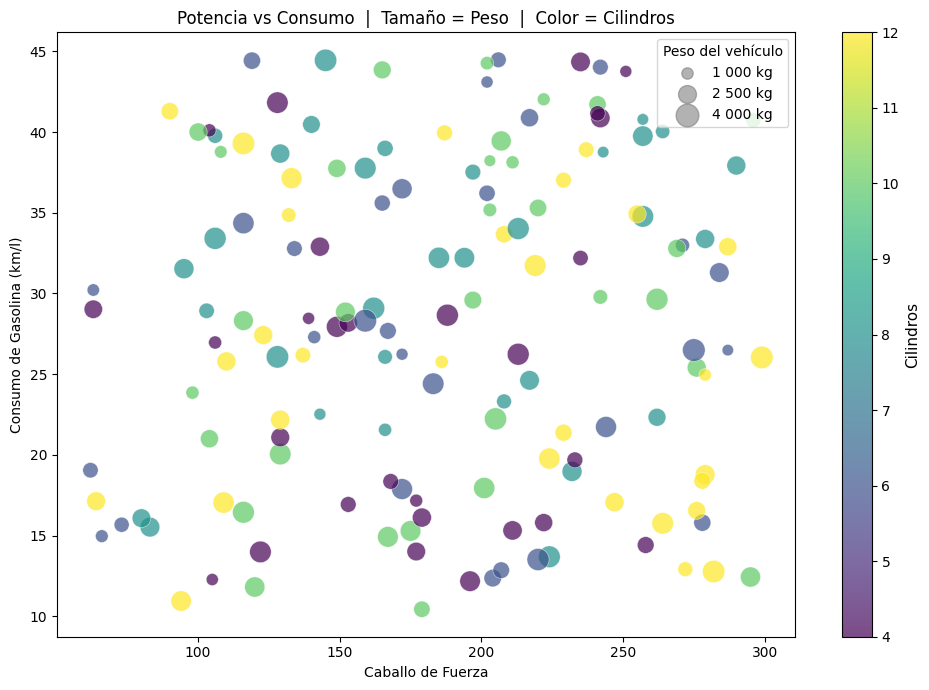

In [13]:
# Ejercicio 11 · Scatter con Doble Codificación
import matplotlib.pyplot as plt

n_autos = 150
df11 = pd.DataFrame({
    "Caballo_Fuerza":   np.random.randint(60, 300, n_autos),
    "Consumo_Gasolina": np.random.uniform(10, 45, n_autos),
    "Peso":             np.random.uniform(1000, 4000, n_autos),
    "Cilindros":        np.random.choice([4, 6, 8, 10, 12], n_autos),
})

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    df11["Caballo_Fuerza"], df11["Consumo_Gasolina"],
    s=df11["Peso"] / 15,           # tamaño = Peso
    c=df11["Cilindros"],            # color  = Cilindros
    cmap="viridis", alpha=0.7, edgecolors="white", linewidth=0.4
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Cilindros", fontsize=11)

# Leyenda manual para el tamaño
for peso, label in zip([1000, 2500, 4000], ["1 000 kg", "2 500 kg", "4 000 kg"]):
    ax.scatter([], [], s=peso/15, c="gray", alpha=0.6, label=label)
ax.legend(title="Peso del vehículo", loc="upper right")

ax.set_xlabel("Caballo de Fuerza")
ax.set_ylabel("Consumo de Gasolina (km/l)")
ax.set_title("Potencia vs Consumo  |  Tamaño = Peso  |  Color = Cilindros")
plt.tight_layout()

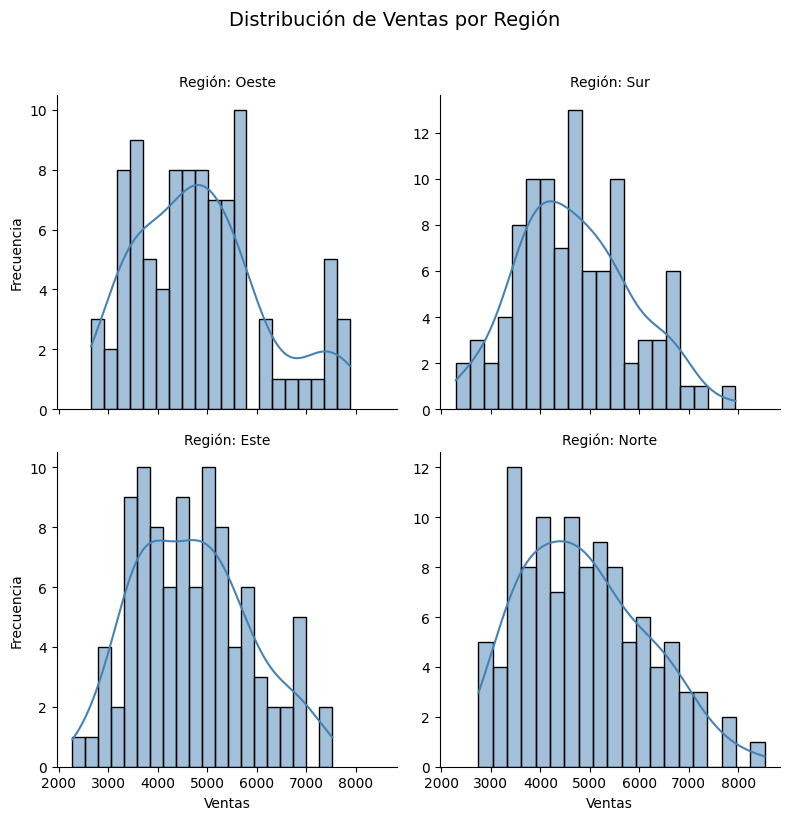

In [15]:
# Ejercicio 12 · FacetGrid con Histograma + KDE
import seaborn as sns

df12 = pd.DataFrame({
    "Region": np.random.choice(["Norte","Sur","Este","Oeste"], 400),
    "Ventas": np.concatenate([
        np.random.normal(5000, 800, 100),
        np.random.normal(3500, 600, 100),
        np.random.normal(6000, 1000, 100),
        np.random.normal(4500, 700, 100),
    ])
})

g = sns.FacetGrid(df12, col="Region", col_wrap=2, height=4, sharey=False)
g.map(sns.histplot, "Ventas", kde=True, bins=20, color="steelblue")
g.set_titles("Región: {col_name}")
g.set_axis_labels("Ventas", "Frecuencia")
g.figure.suptitle("Distribución de Ventas por Región", y=1.02, fontsize=14)
plt.tight_layout()

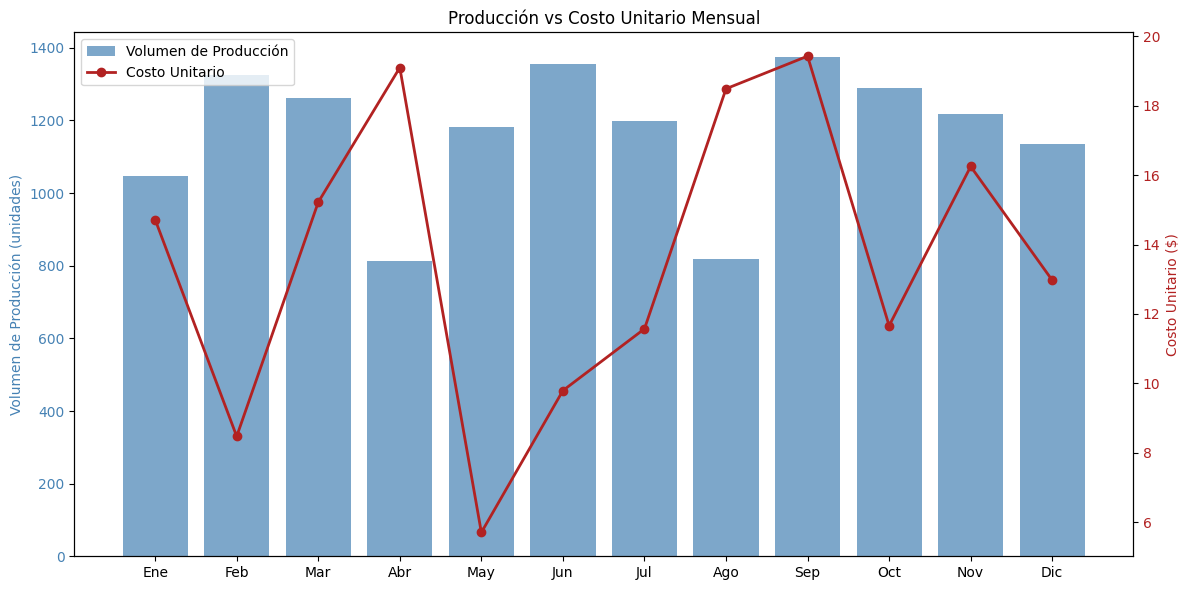

In [16]:
# Ejercicio 13 · Gráfico Multieje (Twinx)
meses      = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
produccion = np.random.randint(800, 1500, 12)
costo_unit = np.round(np.random.uniform(5, 20, 12), 2)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()   # comparte el eje X, crea eje Y derecho

ax1.bar(meses, produccion, color="steelblue", alpha=0.7, label="Volumen de Producción")
ax2.plot(meses, costo_unit, color="firebrick", marker="o", linewidth=2, label="Costo Unitario")

ax1.set_ylabel("Volumen de Producción (unidades)", color="steelblue")
ax2.set_ylabel("Costo Unitario ($)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="firebrick")

# Leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title("Producción vs Costo Unitario Mensual")
plt.tight_layout()


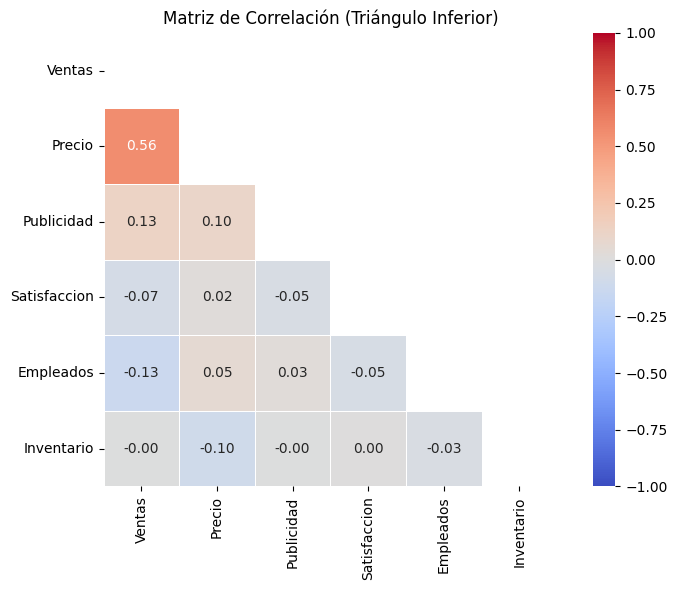

In [17]:
# Ejercicio 14 · Heatmap de Correlación Triangular
df14 = pd.DataFrame(
    np.random.randn(200, 6),
    columns=["Ventas","Precio","Publicidad","Satisfaccion","Empleados","Inventario"]
)
df14["Ventas"] += 0.8 * df14["Precio"]   # correlación artificial

corr = df14.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # oculta triángulo superior

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Matriz de Correlación (Triángulo Inferior)")
plt.tight_layout()

/tmp/ipykernel_10256/429358660.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df15, x="Nivel_Educativo", y="Salario",
/tmp/ipykernel_10256/429358660.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values,


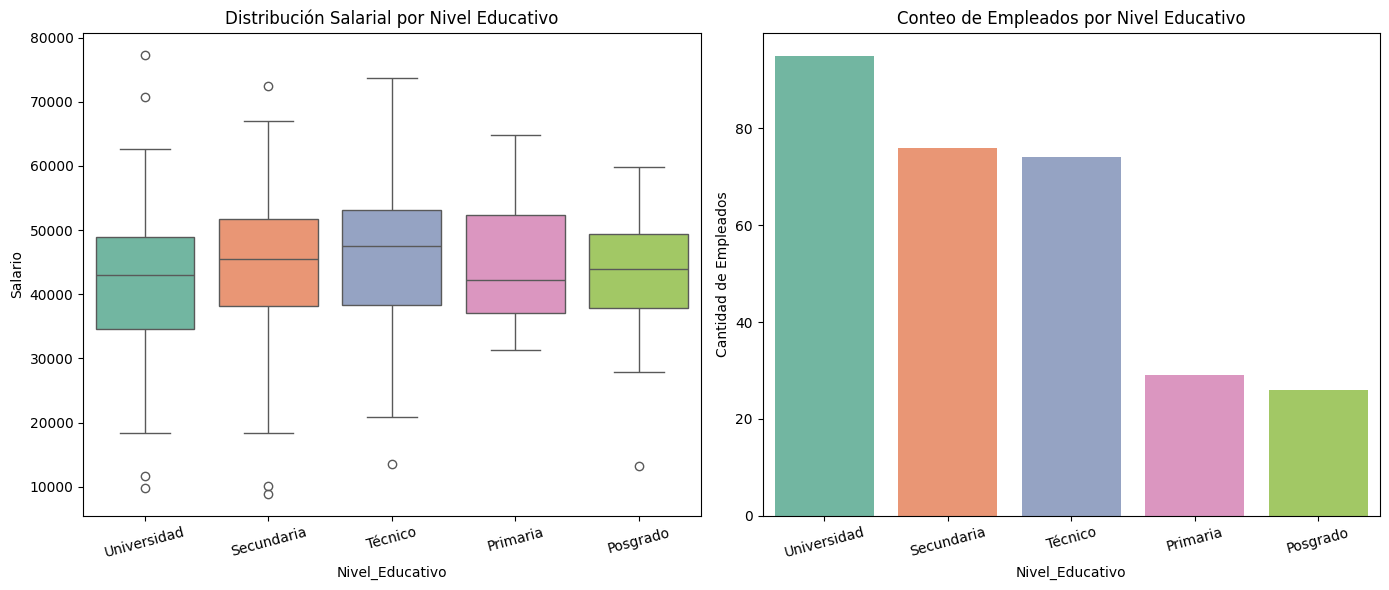

In [18]:
# Ejercicio 15 · Subplots Combinados: Boxplot + Barras
niveles = ["Primaria","Secundaria","Técnico","Universidad","Posgrado"]
df15 = pd.DataFrame({
    "Nivel_Educativo": np.random.choice(niveles, 300, p=[0.10,0.25,0.25,0.30,0.10]),
    "Salario":         np.random.normal(45000, 12000, 300).clip(5000),
})
orden = df15["Nivel_Educativo"].value_counts().index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Boxplot
sns.boxplot(data=df15, x="Nivel_Educativo", y="Salario",
            order=orden, palette="Set2", ax=ax1)
ax1.set_title("Distribución Salarial por Nivel Educativo")
ax1.tick_params(axis="x", rotation=15)

# Subplot 2: Barras de conteo ordenadas de mayor a menor
conteo = df15["Nivel_Educativo"].value_counts()
sns.barplot(x=conteo.index, y=conteo.values,
            order=orden, palette="Set2", ax=ax2)
ax2.set_title("Conteo de Empleados por Nivel Educativo")
ax2.set_ylabel("Cantidad de Empleados")
ax2.tick_params(axis="x", rotation=15)

plt.tight_layout()


In [ ]:
# Bloque 4: Casos Integradores — Análisis + Gráfico


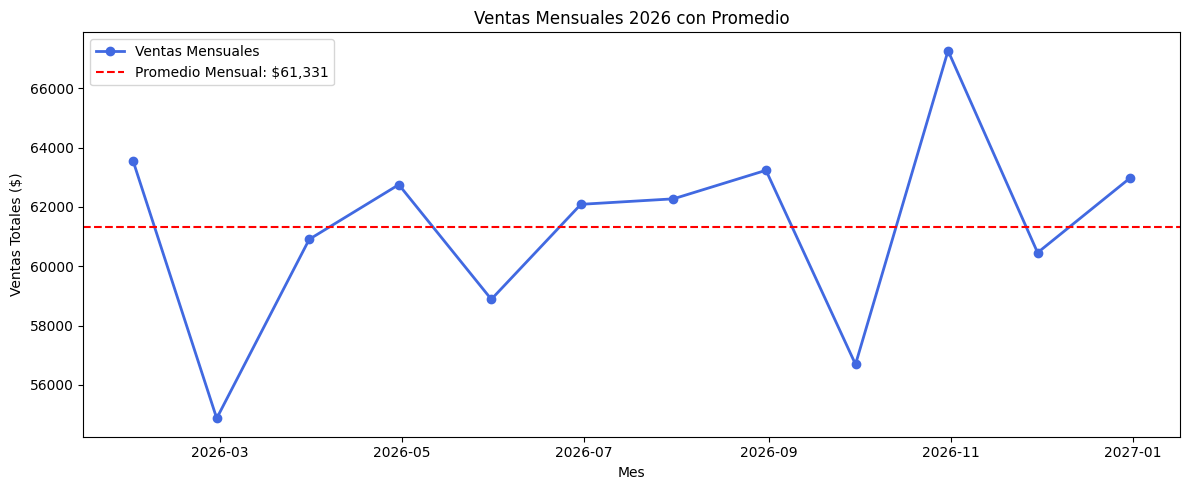

In [20]:
# Ejercicio 16 · Series Temporales y Tendencias

fechas_diarias = pd.date_range("2026-01-01", "2026-12-31", freq="D")
df16 = pd.DataFrame({
    "Fecha":  fechas_diarias,
    "Ventas": np.random.normal(2000, 400, len(fechas_diarias)).clip(500),
})
df16.set_index("Fecha", inplace=True)

# Agrupar por mes y sumar
ventas_mensual = df16["Ventas"].resample("ME").sum()
promedio_mens  = ventas_mensual.mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ventas_mensual.index, ventas_mensual.values,
        marker="o", color="royalblue", linewidth=2, label="Ventas Mensuales")
ax.axhline(promedio_mens, color="red", linestyle="--", linewidth=1.5,
           label=f"Promedio Mensual: ${promedio_mens:,.0f}")
ax.set_title("Ventas Mensuales 2026 con Promedio")
ax.set_xlabel("Mes")
ax.set_ylabel("Ventas Totales ($)")
ax.legend()
plt.tight_layout()

/tmp/ipykernel_10256/3577677789.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Incumplió Pago")


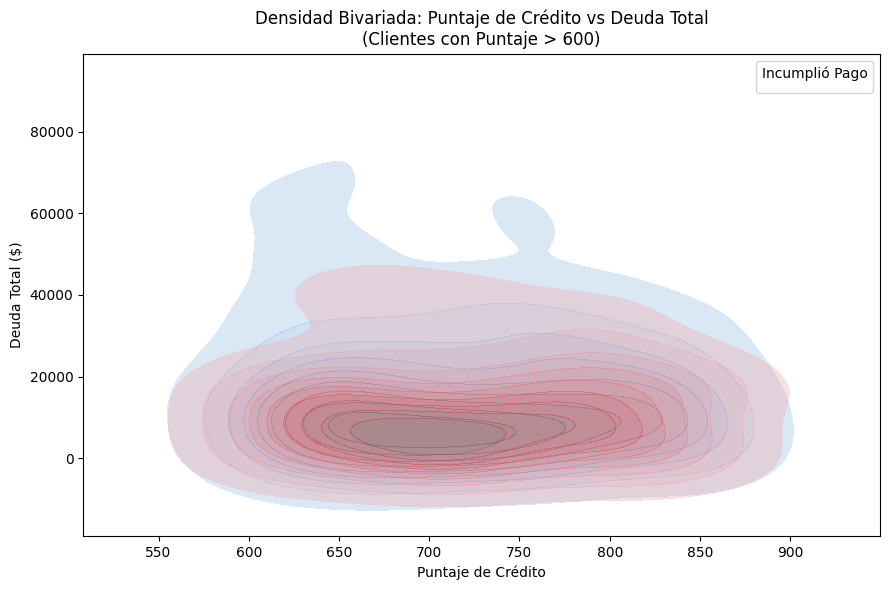

In [21]:
# Ejercicio 17 · Densidad Bivariada de Clientes (KDE)
df17 = pd.DataFrame({
    "Puntaje_Credito": np.random.randint(300, 850, 500),
    "Deuda_Total":     np.random.exponential(15000, 500).clip(0, 80000),
    "Incumplio_Pago":  np.random.choice(["Sí", "No"], 500, p=[0.35, 0.65]),
})

# Filtrar puntaje > 600
df17 = df17[df17["Puntaje_Credito"] > 600]

fig, ax = plt.subplots(figsize=(9, 6))
for grupo, color in zip(["No", "Sí"], ["steelblue", "firebrick"]):
    subset = df17[df17["Incumplio_Pago"] == grupo]
    sns.kdeplot(data=subset, x="Puntaje_Credito", y="Deuda_Total",
                fill=True, alpha=0.4, color=color,
                label=f"Incumplió: {grupo}", ax=ax)

ax.set_title("Densidad Bivariada: Puntaje de Crédito vs Deuda Total\n(Clientes con Puntaje > 600)")
ax.set_xlabel("Puntaje de Crédito")
ax.set_ylabel("Deuda Total ($)")
ax.legend(title="Incumplió Pago")
plt.tight_layout()

Matemáticas     → r=-0.266  p=0.1553
Historia        → r=-0.005  p=0.9791
Ciencias        → r=0.263  p=0.1606


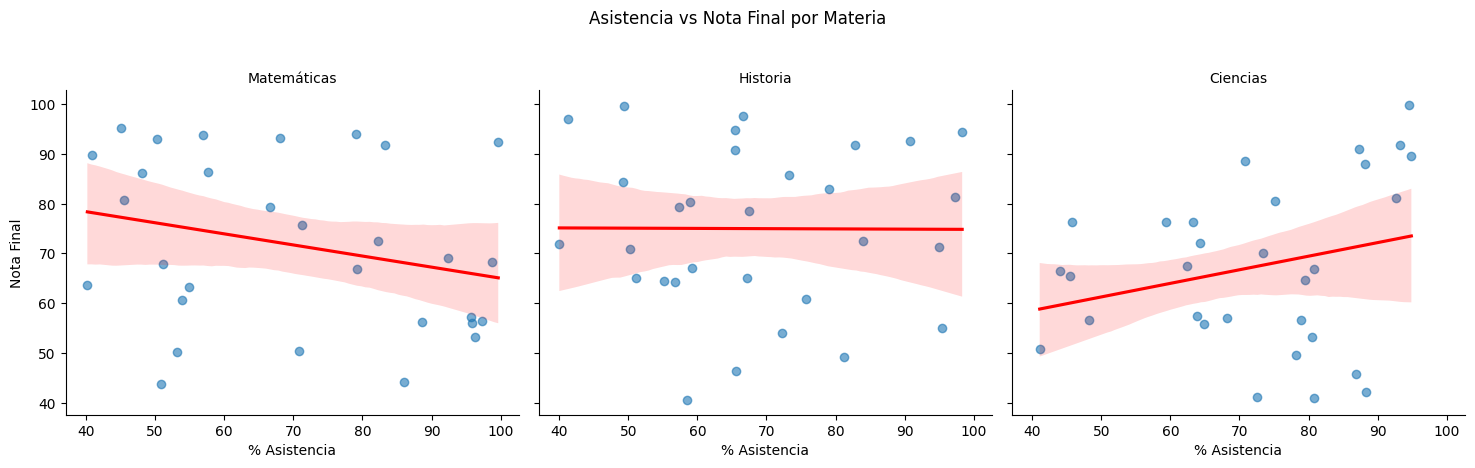

In [22]:
# Ejercicio 18 · Rendimiento Académico y Regresión (lmplot)
materias = ["Matemáticas", "Historia", "Ciencias"]
df18 = pd.DataFrame({
    "Estudiante":            [f"Est_{i}" for i in range(90)],
    "Porcentaje_Asistencia": np.random.uniform(40, 100, 90),
    "Nota_Final":            np.random.uniform(40, 100, 90),
    "Materia":               np.repeat(materias, 30),
})

# Correlación de Pearson por materia
from scipy import stats
for mat in materias:
    sub = df18[df18["Materia"] == mat]
    r, p = stats.pearsonr(sub["Porcentaje_Asistencia"], sub["Nota_Final"])
    print(f"{mat:15s} → r={r:.3f}  p={p:.4f}")

# lmplot: scatter + regresión por materia
g = sns.lmplot(data=df18, x="Porcentaje_Asistencia", y="Nota_Final",
               col="Materia", height=4.5, aspect=1.1,
               scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
g.set_titles("{col_name}")
g.set_axis_labels("% Asistencia", "Nota Final")
g.figure.suptitle("Asistencia vs Nota Final por Materia", y=1.03)
plt.tight_layout()

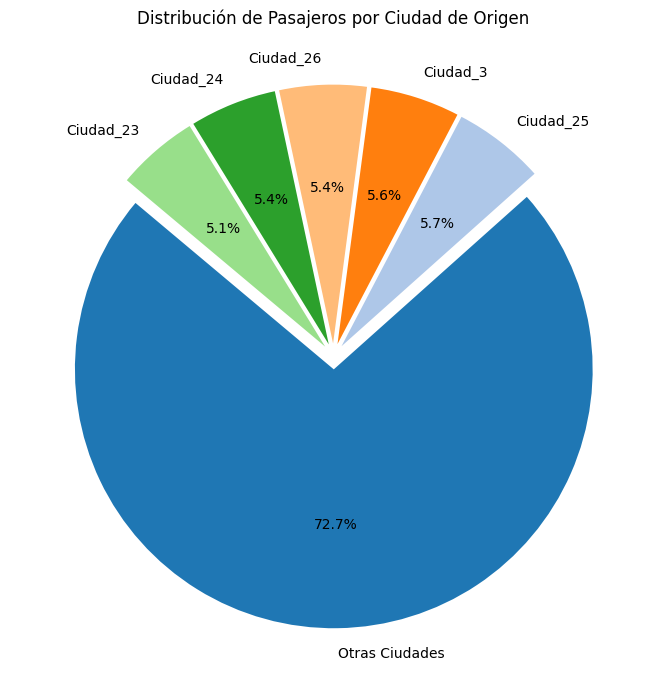

In [23]:
# Ejercicio 19 · Composición con "Otras Ciudades" (Pie Chart)
ciudades  = [f"Ciudad_{i}" for i in range(1, 36)]
pasajeros = np.random.randint(50, 5000, size=35)
df19 = pd.DataFrame({"Ciudad_Origen": ciudades, "Pasajeros": pasajeros})

total = df19["Pasajeros"].sum()
df19["Pct"] = df19["Pasajeros"] / total

# Ciudades con menos del 5% → "Otras Ciudades"
df19["Ciudad_Final"] = df19.apply(
    lambda r: r["Ciudad_Origen"] if r["Pct"] >= 0.05 else "Otras Ciudades",
    axis=1
)

df19_agg = (df19.groupby("Ciudad_Final")["Pasajeros"]
               .sum()
               .reset_index()
               .sort_values("Pasajeros", ascending=False))

fig, ax = plt.subplots(figsize=(9, 7))
ax.pie(df19_agg["Pasajeros"], labels=df19_agg["Ciudad_Final"],
       autopct="%1.1f%%", startangle=140,
       explode=[0.05] * len(df19_agg),
       colors=sns.color_palette("tab20", len(df19_agg)))
ax.set_title("Distribución de Pasajeros por Ciudad de Origen")
plt.tight_layout()

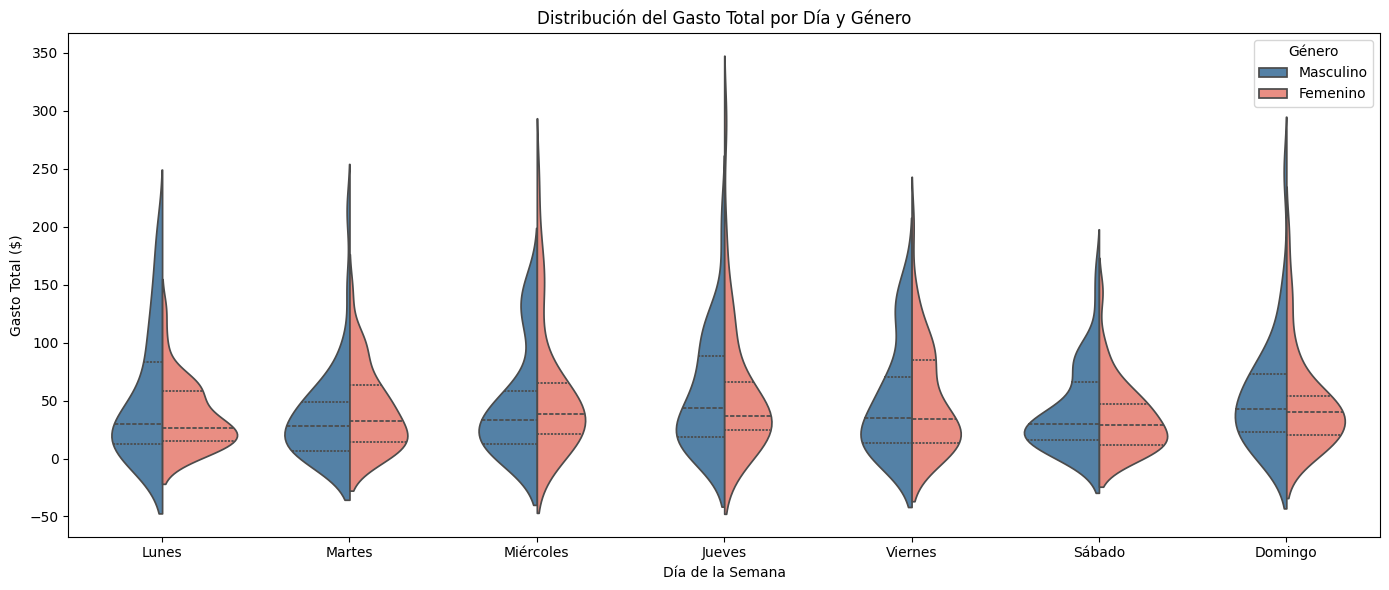

In [24]:
# Ejercicio 20 · Split Violin Plot por Día y Género
dias_orden = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
df20 = pd.DataFrame({
    "Dia_Semana":  np.tile(dias_orden, 80),
    "Gasto_Total": np.random.exponential(50, 560).clip(5, 300),
    "Genero":      np.random.choice(["Masculino","Femenino"], 560),
})
df20["Dia_Semana"] = pd.Categorical(df20["Dia_Semana"],
                                     categories=dias_orden, ordered=True)
df20 = df20.sort_values("Dia_Semana")

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df20, x="Dia_Semana", y="Gasto_Total",
               hue="Genero", split=True, inner="quart",
               palette={"Masculino":"steelblue","Femenino":"salmon"},
               ax=ax)
ax.set_title("Distribución del Gasto Total por Día y Género")
ax.set_xlabel("Día de la Semana")
ax.set_ylabel("Gasto Total ($)")
ax.legend(title="Género", loc="upper right")
plt.tight_layout()